In [1]:
## Build a machine learnig model to predict credit wise loadn system 
## this is a binary classification model
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv");
df.tail()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes
999,1000.0,13093.0,2385.0,Salaried,23.0,Married,1.0,613.0,3.0,0.32,12436.0,25816.0,35818.0,48.0,Personal,Semiurban,Graduate,NaN,Private,No


# Handle missing values

In [ ]:
# When imputer is used we take a 2d array like


In [3]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [6]:
## Data analysis
#df['Applicant_ID'] = df['Applicant_ID'].fillna(pd.Series(df.index + 1, index = df.index))


In [7]:
#df["Employment_Status"].unique()

array(['Salaried', 'Self-employed', 'Contract', 'Unemployed', nan],
      dtype=object)

In [5]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns  ## juts use number to include all the numerical values

In [6]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [7]:
numerical_cols.size + categorical_cols.size

20

# We have a module named imputer

In [8]:
#sklearn imputer - used to complete values with simple strategies
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [9]:
cat_imp = SimpleImputer(strategy = "most_frequent")   ## here for categorical objects it is most_frequent
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [10]:
df[categorical_cols].isnull().sum()

Employment_Status    0
Marital_Status       0
Loan_Purpose         0
Property_Area        0
Education_Level      0
Gender               0
Employer_Category    0
Loan_Approved        0
dtype: int64

Text(0.5, 1.0, 'Is loan approved or not')

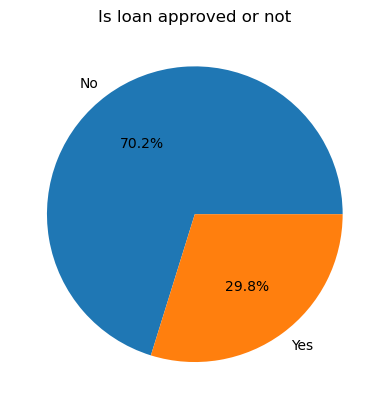

In [11]:
## we create different plots to analyse how the feature of the data behave
# how balance are our classes
classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is loan approved or not")

[Text(0, 0, '722'), Text(0, 0, '278')]

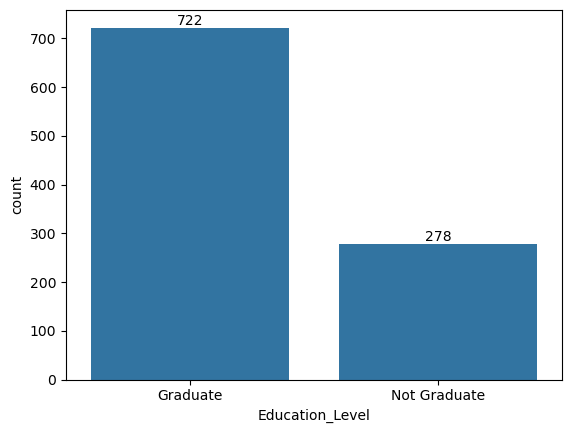

In [12]:
## analyse categories
# gender_cnt = df["Gender"].value_counts()
# ax = sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0])

edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

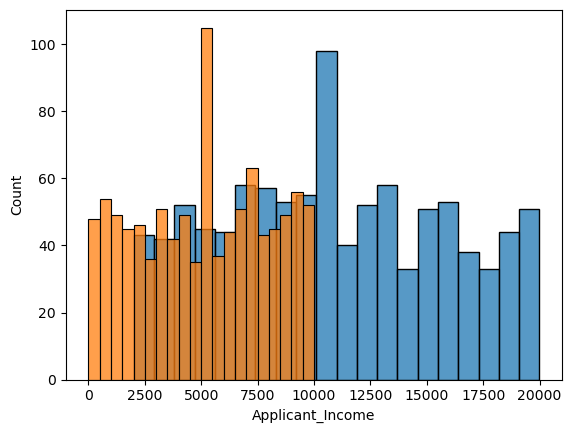

In [13]:
# analyse income 
sns.histplot(
    data =df,
    x = "Applicant_Income",
    bins = 20
)

sns.histplot(
    data =df,
    x = "Coapplicant_Income",
    bins = 20
)

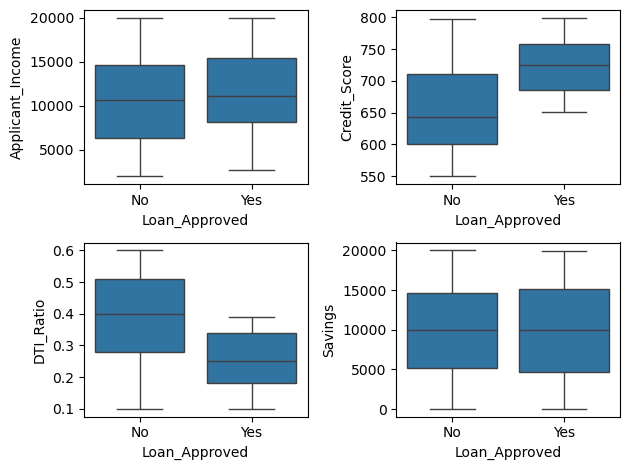

In [14]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data = df,x = "Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data = df,x = "Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0], data = df,x = "Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data = df,x = "Loan_Approved",y="Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

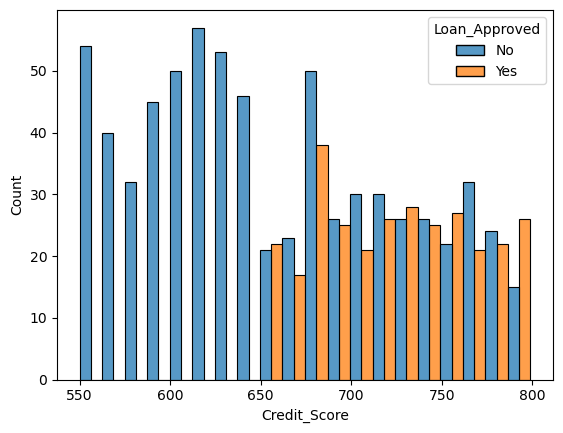

In [15]:
## relation of credit score and loan approved

sns.histplot(
    data = df,
    x ="Credit_Score",
    hue="Loan_Approved",
    bins =20,
    multiple="dodge"
)

In [17]:
## Remove the applicantID - cause it is not of that much use 
#df = df.drop("Applicant_ID", axis =1)
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

# Encoding

In [15]:
# we have  binary endoing and onehotencoding
## NEW WAY IS SKLEARN LabelEncoder and OneHotEncoder

from sklearn.preprocessing import LabelEncoder , OneHotEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])


In [16]:
cols= ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]

ohe = OneHotEncoder(drop="first",sparse_output = False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])

## pandas encoded dataframe
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index = df.index)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [17]:
df.head()
df.isnull().sum()

Applicant_ID                       0
Applicant_Income                   0
Coapplicant_Income                 0
Age                                0
Dependents                         0
Credit_Score                       0
Existing_Loans                     0
DTI_Ratio                          0
Savings                            0
Collateral_Value                   0
Loan_Amount                        0
Loan_Term                          0
Education_Level                    0
Loan_Approved                      0
Employment_Status_Salaried         0
Employment_Status_Self-employed    0
Employment_Status_Unemployed       0
Marital_Status_Single              0
Loan_Purpose_Car                   0
Loan_Purpose_Education             0
Loan_Purpose_Home                  0
Loan_Purpose_Personal              0
Property_Area_Semiurban            0
Property_Area_Urban                0
Gender_Male                        0
Employer_Category_Government       0
Employer_Category_MNC              0
E

# Correlation HeatMap

In [20]:
## Visual representation of the relationships between diffferent variables in a dataset

In [18]:
num_cols = df.select_dtypes(include=["number"])
corr_matrix = num_cols.corr()

In [19]:
num_cols.corr()["Loan_Approved"].sort_values(ascending= False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed    

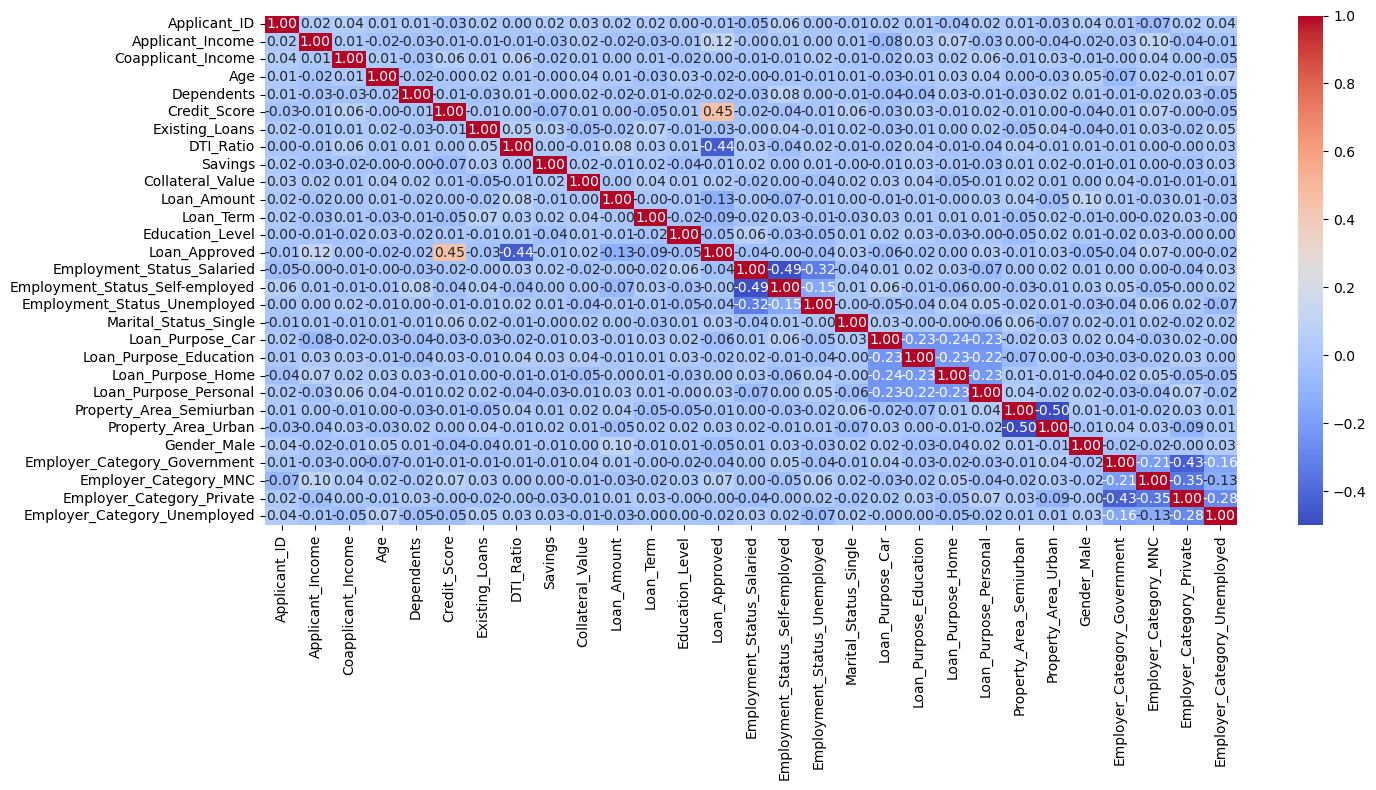

In [20]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot= True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.tight_layout()

# Train-Test-Split + Feature Scaling

In [21]:
x = df.drop("Loan_Approved", axis =1)
y = df["Loan_Approved"]

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state =42)

In [23]:
x_train.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,30.0,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,536.0,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,696.0,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,558.0,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,837.0,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [25]:
x_train_scaled

array([[-1.66336551, -1.01234556,  1.02716377, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [ 0.1281584 , -1.23639141, -1.59187898, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [ 0.69464817, -0.01158625,  1.33606578, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [ 1.27884075, -0.22727759,  0.35008962, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 0.00501768,  1.12970221, -0.46470044, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-1.40490455, -1.75526629,  0.01434173, ...,  2.416114  ,
        -0.85972695, -0.30723158]], shape=(800, 28))

# Train and Evaluate

In [26]:
## Logistic regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

y_pred = log_model.predict(x_test_scaled)

## Evaluate 
#Precision and Recall
## for laon based tasks precision is more important 

#Evaluation
print("Precision: ", precision_score(y_test,y_pred))
print("Recall: ", recall_score(y_test,y_pred))
print("F1 Score: ", f1_score(y_test,y_pred))
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("Confusion Matrix: ", confusion_matrix(y_test,y_pred))


Precision:  0.7868852459016393
Recall:  0.7868852459016393
F1 Score:  0.7868852459016393
Accuracy:  0.87
Confusion Matrix:  [[126  13]
 [ 13  48]]


In [35]:
## KNN Classifier
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train )
y_pred = knn_model.predict(x_test_scaled)


#Evaluation
print("Precision: ", precision_score(y_test,y_pred))
print("Recall: ", recall_score(y_test,y_pred))
print("F1 Score: ", f1_score(y_test,y_pred))
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("Confusion Matrix: ", confusion_matrix(y_test,y_pred))

Precision:  0.5957446808510638
Recall:  0.45901639344262296
F1 Score:  0.5185185185185185
Accuracy:  0.74
Confusion Matrix:  [[120  19]
 [ 33  28]]


In [39]:
## Naive bayes 
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)
y_pred = nb_model.predict(x_test_scaled)

#Evaluation
print("Precision: ", precision_score(y_test,y_pred))
print("Recall: ", recall_score(y_test,y_pred))
print("F1 Score: ", f1_score(y_test,y_pred))
print("Accuracy: ", accuracy_score(y_test,y_pred))
print("Confusion Matrix: ", confusion_matrix(y_test,y_pred))

Precision:  0.8035714285714286
Recall:  0.7377049180327869
F1 Score:  0.7692307692307693
Accuracy:  0.865
Confusion Matrix:  [[128  11]
 [ 16  45]]


## Feature Engineering 

In [ ]:
df["DTI_Ratio _sq"] = df["DTI_Ratio"] ** 2